# Record Pairs: Single-Image Tiled Inference

This notebook runs the stage-1 segmentation model on a **single image** from `record_pairs` using tile inference, merges tile predictions back to original image size, and overlays:
- GT annotation bboxes (`label_name=vehicle`)
- Predicted mask and predicted bboxes


In [25]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("notebook")
%matplotlib inline
from matplotlib.patches import Rectangle
from PIL import Image

import torch
import torch.nn.functional as F

from train_stage1_seg import load_records
from eval_stage1_seg import Stage1SegNet, infer_segmentation_on_image, connected_components


In [26]:
# ---- Config ----
DATA_DIR = Path('/home/schelli/git/wtcv/data/record_pairs')#Path("/home/schelli/git/wtcv/data/war_thunder_tank_detection_labelme_pairs_1perc")
CHECKPOINT = Path('/home/schelli/git/wtcv/runs/20260211-180651-wt_1perc_30k_10ep_val3/checkpoints/final.pt')
LABEL_NAME = 'vehicle'

# Set one explicit image path from record_pairs.
# If None, the first record is used.
IMAGE_PATH = None
# Example:
# IMAGE_PATH = DATA_DIR / 'your_image_name.png'

TILE_SIZE = 224
TILE_STRIDE = 112
SEG_OUT_STRIDE = 4
PRED_THRESHOLD = 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
print('data_dir:', DATA_DIR)
print('checkpoint:', CHECKPOINT)


device: cuda
data_dir: /home/schelli/git/wtcv/data/record_pairs
checkpoint: /home/schelli/git/wtcv/runs/20260211-180651-wt_1perc_30k_10ep_val3/checkpoints/final.pt


In [27]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Missing data dir: {DATA_DIR}')
if not CHECKPOINT.exists():
    raise FileNotFoundError(f'Missing checkpoint: {CHECKPOINT}')

records = load_records(DATA_DIR, LABEL_NAME, min_poly_points=3)
if not records:
    raise RuntimeError('No records loaded. Check DATA_DIR/LABEL_NAME.')

if IMAGE_PATH is None:
    idx = np.random.choice(len(records))
    rec = records[idx]
else:
    target = str(Path(IMAGE_PATH).resolve())
    rec = None
    for r in records:
        if str(Path(r['image_path']).resolve()) == target:
            rec = r
            break
    if rec is None:
        raise ValueError(f'IMAGE_PATH not found in loaded records: {IMAGE_PATH}')

print('selected image:', rec['image_path'])
print('num objects:', len(rec['objects']))


selected image: /home/schelli/git/wtcv/data/record_pairs/000605.png
num objects: 2


In [28]:
# Load model and checkpoint
model = Stage1SegNet(channels=256, trust_repo=True).to(DEVICE)
try:
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
except Exception as e:
    warnings.warn(
        'weights_only=True failed; falling back to weights_only=False. Use trusted checkpoints only. '
        f'Error: {e}'
    )
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)

state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
model.load_state_dict(state, strict=True)
model.eval()
print('checkpoint loaded')


Using cache found in /home/schelli/.cache/torch/hub/facebookresearch_dinov2_main


checkpoint loaded


/tmp/ipykernel_62006/3547415757.py:6: UserWarning: weights_only=True failed; falling back to weights_only=False. Use trusted checkpoints only. Error: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pathlib._local.PosixPath was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pathlib._local.PosixPath])` or the `torch.serialization.safe_globals([pathlib._local.PosixPath])` context manag

In [29]:
# Run tiled inference and merge in low-res grid space
img_np = np.array(Image.open(rec['image_path']).convert('RGB'), dtype=np.uint8)
H, W = img_np.shape[:2]

prob_lr = infer_segmentation_on_image(
    model=model,
    image_np=img_np,
    tile_size=TILE_SIZE,
    stride=TILE_STRIDE,
    seg_out_stride=SEG_OUT_STRIDE,
    device=DEVICE,
)
pred_lr = (prob_lr >= PRED_THRESHOLD).astype(np.uint8)

# Upsample merged prediction back to original image size
t_prob = torch.from_numpy(prob_lr).float().unsqueeze(0).unsqueeze(0)
prob_full = F.interpolate(t_prob, size=(H, W), mode='bilinear', align_corners=False)[0, 0].numpy()
pred_full = (prob_full >= PRED_THRESHOLD).astype(np.uint8)

print('image size:', (W, H))
print('low-res map size:', prob_lr.shape[::-1], '(W,H)')
print('pred positive pixels (full):', int(pred_full.sum()))


image size: (1280, 720)
low-res map size: (320, 180) (W,H)
pred positive pixels (full): 16214


In [30]:
def gt_boxes_from_record(record):
    boxes = []
    for obj in record['objects']:
        x0, y0, x1, y1 = obj['bbox_xyxy']
        boxes.append((float(x0), float(y0), float(x1), float(y1)))
    return boxes

def pred_boxes_from_lr_components(pred_lr_mask, seg_out_stride):
    boxes = []
    comps = connected_components(pred_lr_mask.astype(np.uint8))
    for c in comps:
        ys, xs = np.where(c > 0)
        if ys.size == 0:
            continue
        x0_lr, x1_lr = xs.min(), xs.max() + 1
        y0_lr, y1_lr = ys.min(), ys.max() + 1
        x0 = float(x0_lr * seg_out_stride)
        y0 = float(y0_lr * seg_out_stride)
        x1 = float(x1_lr * seg_out_stride)
        y1 = float(y1_lr * seg_out_stride)
        boxes.append((x0, y0, x1, y1))
    return boxes

gt_boxes = gt_boxes_from_record(rec)
pred_boxes = pred_boxes_from_lr_components(pred_lr, SEG_OUT_STRIDE)

print('gt boxes:', len(gt_boxes))
print('pred boxes:', len(pred_boxes))


gt boxes: 2
pred boxes: 12


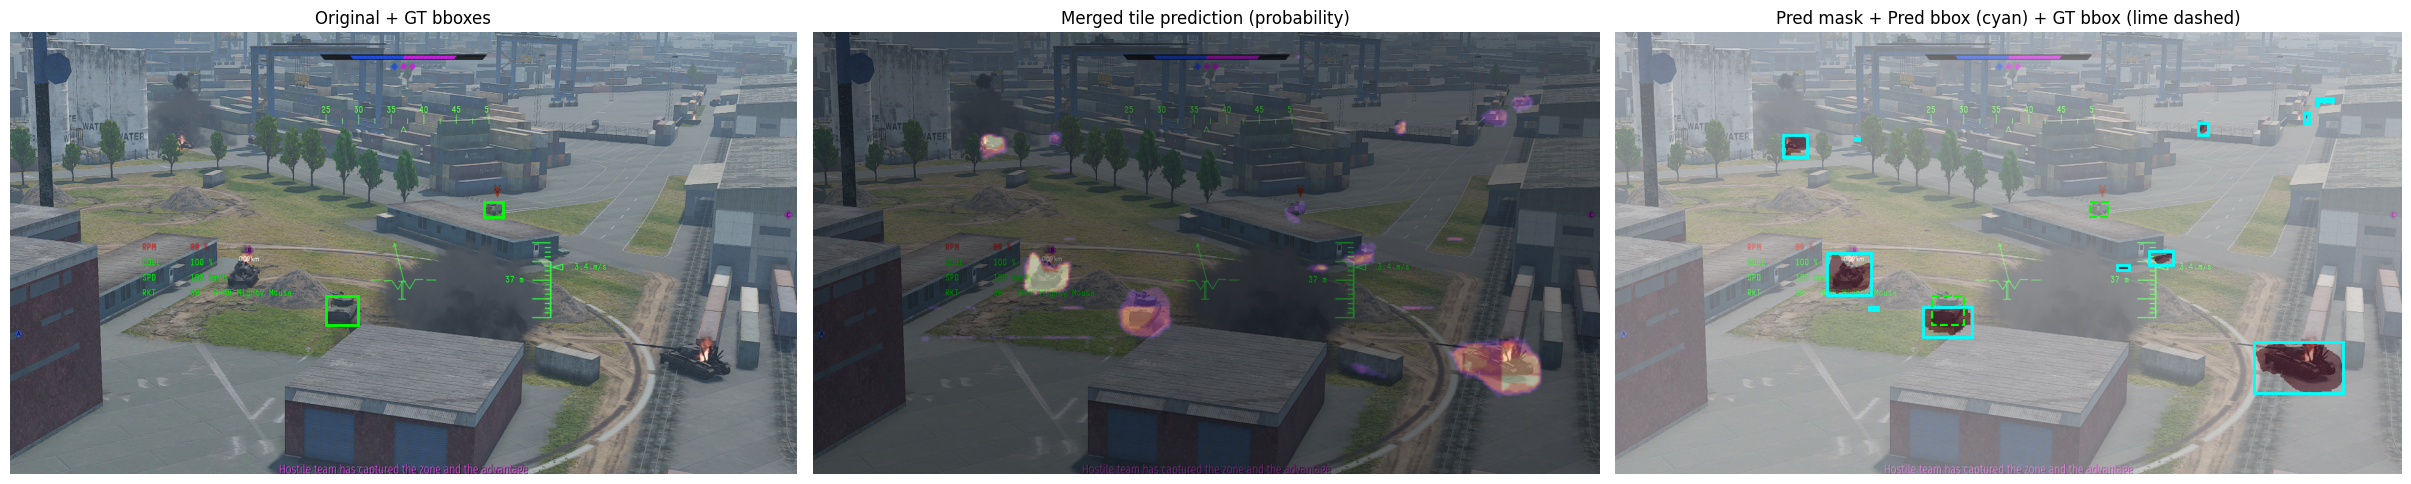

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

# Panel 1: original + GT bbox
axes[0].imshow(img_np)
axes[0].set_title('Original + GT bboxes')
for (x0, y0, x1, y1) in gt_boxes:
    axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=2))
axes[0].axis('off')

# Panel 2: merged probability heatmap (full size)
axes[1].imshow(img_np)
axes[1].imshow(prob_full, cmap='magma', alpha=0.45, vmin=0.0, vmax=1.0)
axes[1].set_title('Merged tile prediction (probability)')
axes[1].axis('off')

# Panel 3: prediction mask + predicted bbox + GT bbox
axes[2].imshow(img_np)
axes[2].imshow(pred_full, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
for (x0, y0, x1, y1) in pred_boxes:
    axes[2].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='cyan', linewidth=2))
for (x0, y0, x1, y1) in gt_boxes:
    axes[2].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=1.5, linestyle='--'))
axes[2].set_title('Pred mask + Pred bbox (cyan) + GT bbox (lime dashed)')
axes[2].axis('off')

plt.show()


In [32]:
# Optional: quick overlap stats against GT union mask
gt_union = np.zeros((H, W), dtype=np.uint8)
for (x0, y0, x1, y1) in gt_boxes:
    x0i, y0i = max(0, int(np.floor(x0))), max(0, int(np.floor(y0)))
    x1i, y1i = min(W, int(np.ceil(x1))), min(H, int(np.ceil(y1)))
    if x1i > x0i and y1i > y0i:
        gt_union[y0i:y1i, x0i:x1i] = 1

inter = np.logical_and(pred_full > 0, gt_union > 0).sum()
union = np.logical_or(pred_full > 0, gt_union > 0).sum()
iou = float(inter / union) if union > 0 else 1.0
print({'pred_pixels': int(pred_full.sum()), 'gt_pixels': int(gt_union.sum()), 'bbox_union_iou': iou})


{'pred_pixels': 16214, 'gt_pixels': 3341, 'bbox_union_iou': 0.08723451573446013}
